<a href="https://colab.research.google.com/github/TasnimMahfuz/seq2seq-codegen/blob/main/text_to_code.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import drive
drive.mount('/content/drive')

PROJECT_DIR = "/content/drive/MyDrive/SeqToSeq"
import os
os.makedirs(PROJECT_DIR, exist_ok=True)
os.chdir(PROJECT_DIR)

print(f"Working directory: {os.getcwd()}")
print(f"Files in directory: {os.listdir(PROJECT_DIR)}")

Mounted at /content/drive
Working directory: /content/drive/MyDrive/SeqToSeq
Files in directory: []


In [2]:
!pip install datasets torchtext matplotlib seaborn nltk sacrebleu

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 37.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 100.8/100.8 kB 12.4 MB/s eta 0:00:00


Necessary library imports (Basic Scientific Python packages, Pytorch packages, Huggingface utils etc) follow. Usually, seed is set to be 42 as a literary reference. In
The Hitchhiker's Guide to the Galaxy, 42 is the "Answer to the Ultimate Question of Life, the Universe, and Everything" computed by a supercomputer for millions of years, although the ultimate question remains unknown. In my case, I will choose the seed to be 71, which is the year our nation was born.  


In [3]:
import numpy as np
import pandas as pd
import os
import random
import re
import collections
from collections import Counter

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader


from datasets import load_dataset

# For reproducibility
SEED = 71
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False


device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"Memory Available: {torch.cuda.get_device_properties(0).total_memory / 1e9:.2f} GB")

Using device: cuda
GPU: Tesla T4
Memory Available: 15.64 GB


### Dataset Processing

In [4]:
data_set = load_dataset("Nan-Do/code-search-net-python")

README.md: 0.00B [00:00, ?B/s]

data/train-00000-of-00004-ee77a7de79eb2a(…):   0%|          | 0.00/155M [00:00<?, ?B/s]

data/train-00001-of-00004-648b3bede2edf6(…):   0%|          | 0.00/139M [00:00<?, ?B/s]

data/train-00002-of-00004-1dfd72b171e6b2(…):   0%|          | 0.00/153M [00:00<?, ?B/s]

data/train-00003-of-00004-184ab6d0e3c690(…):   0%|          | 0.00/151M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/455243 [00:00<?, ? examples/s]

In [5]:
import pickle


MAX_DOCSTRING_LENGTH = 50
MAX_CODE_LENGTH = 80
NUM_TRAIN_SAMPLES = 10000
NUM_VAL_SAMPLES = 1500
NUM_TEST_SAMPLES = 1500

def tokenize(text):
    text = text.lower()
    text = re.sub(r"\s+", " ", text)
    return text.strip().split()

class Vocabulary:
    def __init__(self):

        self.PAD_TOKEN = "<pad>"
        self.UNK_TOKEN = "<unk>"
        self.SOS_TOKEN = "<sos>"
        self.EOS_TOKEN = "<eos>"

        self.word2idx = {
            self.PAD_TOKEN: 0,
            self.UNK_TOKEN: 1,
            self.SOS_TOKEN: 2,
            self.EOS_TOKEN: 3
        }

        self.idx2word = {
            0: self.PAD_TOKEN,
            1: self.UNK_TOKEN,
            2: self.SOS_TOKEN,
            3: self.EOS_TOKEN
        }

        self.word_count = {}
        self.n_words = 4

    def add_sentence(self, sentence):
        for word in sentence.split():
            self.add_word(word)

    def add_word(self, word):
        if word not in self.word2idx:
            self.word2idx[word] = self.n_words
            self.idx2word[self.n_words] = word
            self.word_count[word] = 1
            self.n_words += 1
        else:
            if word not in [self.PAD_TOKEN, self.UNK_TOKEN, self.SOS_TOKEN, self.EOS_TOKEN]:
                self.word_count[word] += 1

    def sentence_to_indices(self, sentence, max_length):
        tokens = sentence.split()[:max_length]

        indices = [
            self.word2idx.get(word, self.word2idx[self.UNK_TOKEN])
            for word in tokens
        ]


        indices = (
            [self.word2idx[self.SOS_TOKEN]]
            + indices
            + [self.word2idx[self.EOS_TOKEN]]
        )

        return indices

    def indices_to_sentence(self, indices):
        words = []
        for idx in indices:
            word = self.idx2word.get(idx, self.UNK_TOKEN)

            if word in [self.PAD_TOKEN, self.SOS_TOKEN]:
                continue
            if word == self.EOS_TOKEN:
                break

            words.append(word)

        return " ".join(words)


def preprocess_data(dataset_split, num_samples):
    data = []

    for example in dataset_split:
        if len(data) >= num_samples:
            break

        try:
            doc_tokens = example.get("docstring_tokens", [])
            code_tokens = example.get("code_tokens", [])


            if not doc_tokens or not code_tokens:
                continue


            if (len(doc_tokens) > 0 and len(doc_tokens) <= MAX_DOCSTRING_LENGTH and
                len(code_tokens) > 0 and len(code_tokens) <= MAX_CODE_LENGTH):
                data.append({
                    'docstring': ' '.join(doc_tokens),
                    'code': ' '.join(code_tokens)
                })

        except Exception as e:
            continue

    return data


print("Preprocessing data...")
total_samples_needed = NUM_TRAIN_SAMPLES + NUM_VAL_SAMPLES + NUM_TEST_SAMPLES
all_data = preprocess_data(data_set['train'], total_samples_needed)

print(f"Total samples collected: {len(all_data)}")


random.seed(SEED)
random.shuffle(all_data)


train_data = all_data[:NUM_TRAIN_SAMPLES]
val_data = all_data[NUM_TRAIN_SAMPLES:NUM_TRAIN_SAMPLES + NUM_VAL_SAMPLES]
test_data = all_data[NUM_TRAIN_SAMPLES + NUM_VAL_SAMPLES:NUM_TRAIN_SAMPLES + NUM_VAL_SAMPLES + NUM_TEST_SAMPLES]

print(f"\nTrain samples: {len(train_data)}")
print(f"Val samples: {len(val_data)}")
print(f"Test samples: {len(test_data)}")

if len(train_data) > 0:
    print(f"\nSample example:")
    print(f"Docstring: {train_data[0]['docstring'][:150]}...")
    print(f"Code: {train_data[0]['code'][:150]}...")


print("\nBuilding vocabularies...")
src_vocab = Vocabulary()
tgt_vocab = Vocabulary()

for pair in train_data:
    src_vocab.add_sentence(pair['docstring'])
    tgt_vocab.add_sentence(pair['code'])

print(f"Source vocab size: {src_vocab.n_words}")
print(f"Target vocab size: {tgt_vocab.n_words}")


with open(os.path.join(PROJECT_DIR, 'src_vocab.pkl'), 'wb') as f:
    pickle.dump(src_vocab, f)
with open(os.path.join(PROJECT_DIR, 'tgt_vocab.pkl'), 'wb') as f:
    pickle.dump(tgt_vocab, f)


with open(os.path.join(PROJECT_DIR, 'train_data.pkl'), 'wb') as f:
    pickle.dump(train_data, f)
with open(os.path.join(PROJECT_DIR, 'val_data.pkl'), 'wb') as f:
    pickle.dump(val_data, f)
with open(os.path.join(PROJECT_DIR, 'test_data.pkl'), 'wb') as f:
    pickle.dump(test_data, f)

Preprocessing data...
Total samples collected: 13000

Train samples: 10000
Val samples: 1500
Test samples: 1500

Sample example:
Docstring: Return whether a string has open quotes ....
Code: def unmatched_quotes_in_line ( text ) : # We check " first, then ', so complex cases with nested quotes will # get the " to take precedence. text = te...

Building vocabularies...
Source vocab size: 10260
Target vocab size: 42007


In [6]:
class CodeGenerationDataset(Dataset):
    def __init__(self, data, src_vocab, tgt_vocab):
        self.data = data
        self.src_vocab = src_vocab
        self.tgt_vocab = tgt_vocab

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        pair = self.data[idx]
        src_indices = self.src_vocab.sentence_to_indices(
            pair['docstring'], MAX_DOCSTRING_LENGTH)
        tgt_indices = self.tgt_vocab.sentence_to_indices(
            pair['code'], MAX_CODE_LENGTH)
        return torch.tensor(src_indices), torch.tensor(tgt_indices)

def collate_fn(batch):
    src_batch, tgt_batch = zip(*batch)

    src_lengths = [len(s) for s in src_batch]
    tgt_lengths = [len(t) for t in tgt_batch]

    max_src_len = max(src_lengths)
    max_tgt_len = max(tgt_lengths)

    src_padded = torch.zeros(len(batch), max_src_len, dtype=torch.long)
    tgt_padded = torch.zeros(len(batch), max_tgt_len, dtype=torch.long)

    for i, (src, tgt) in enumerate(zip(src_batch, tgt_batch)):
        src_padded[i, :len(src)] = src
        tgt_padded[i, :len(tgt)] = tgt

    return src_padded, tgt_padded, torch.tensor(src_lengths), torch.tensor(tgt_lengths)

train_dataset = CodeGenerationDataset(train_data, src_vocab, tgt_vocab)
val_dataset = CodeGenerationDataset(val_data, src_vocab, tgt_vocab)
test_dataset = CodeGenerationDataset(test_data, src_vocab, tgt_vocab)


BATCH_SIZE = 32
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, collate_fn=collate_fn)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate_fn)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate_fn)

print(f"DataLoaders created!")
print(f"Train batches: {len(train_loader)}")
print(f"Val batches: {len(val_loader)}")
print(f"Test batches: {len(test_loader)}")

DataLoaders created!
Train batches: 313
Val batches: 47
Test batches: 47


In [7]:
class EncoderRNN(nn.Module):
    def __init__(self, input_size, embedding_dim, hidden_dim):
        super(EncoderRNN, self).__init__()
        self.hidden_dim = hidden_dim
        self.embedding = nn.Embedding(input_size, embedding_dim, padding_idx=0)
        self.rnn = nn.RNN(embedding_dim, hidden_dim, batch_first=True)

    def forward(self, src, src_lengths):
        embedded = self.embedding(src)
        outputs, hidden = self.rnn(embedded)
        return outputs, hidden

class DecoderRNN(nn.Module):
    def __init__(self, output_size, embedding_dim, hidden_dim):
        super(DecoderRNN, self).__init__()
        self.embedding = nn.Embedding(output_size, embedding_dim, padding_idx=0)
        self.rnn = nn.RNN(embedding_dim, hidden_dim, batch_first=True)
        self.out = nn.Linear(hidden_dim, output_size)

    def forward(self, input, hidden):
        embedded = self.embedding(input)
        output, hidden = self.rnn(embedded, hidden)
        prediction = self.out(output)
        return prediction, hidden

class Seq2SeqRNN(nn.Module):
    def __init__(self, encoder, decoder, device):
        super(Seq2SeqRNN, self).__init__()
        self.encoder = encoder
        self.decoder = decoder
        self.device = device

    def forward(self, src, tgt, src_lengths, teacher_forcing_ratio=0.5):
        batch_size = src.shape[0]
        tgt_len = tgt.shape[1]
        tgt_vocab_size = self.decoder.out.out_features

        outputs = torch.zeros(batch_size, tgt_len, tgt_vocab_size).to(self.device)

        encoder_outputs, hidden = self.encoder(src, src_lengths)

        input = tgt[:, 0].unsqueeze(1)

        for t in range(1, tgt_len):
            output, hidden = self.decoder(input, hidden)
            outputs[:, t, :] = output.squeeze(1)

            teacher_force = random.random() < teacher_forcing_ratio
            top1 = output.argmax(2)
            input = tgt[:, t].unsqueeze(1) if teacher_force else top1

        return outputs

In [8]:
# Model 2: LSTM
class EncoderLSTM(nn.Module):
    def __init__(self, input_size, embedding_dim, hidden_dim):
        super(EncoderLSTM, self).__init__()
        self.hidden_dim = hidden_dim
        self.embedding = nn.Embedding(input_size, embedding_dim, padding_idx=0)
        self.lstm = nn.LSTM(embedding_dim, hidden_dim, batch_first=True)

    def forward(self, src, src_lengths):
        embedded = self.embedding(src)
        outputs, (hidden, cell) = self.lstm(embedded)
        return outputs, hidden, cell

class DecoderLSTM(nn.Module):
    def __init__(self, output_size, embedding_dim, hidden_dim):
        super(DecoderLSTM, self).__init__()
        self.embedding = nn.Embedding(output_size, embedding_dim, padding_idx=0)
        self.lstm = nn.LSTM(embedding_dim, hidden_dim, batch_first=True)
        self.out = nn.Linear(hidden_dim, output_size)

    def forward(self, input, hidden, cell):
        embedded = self.embedding(input)
        output, (hidden, cell) = self.lstm(embedded, (hidden, cell))
        prediction = self.out(output)
        return prediction, hidden, cell

class Seq2SeqLSTM(nn.Module):
    def __init__(self, encoder, decoder, device):
        super(Seq2SeqLSTM, self).__init__()
        self.encoder = encoder
        self.decoder = decoder
        self.device = device

    def forward(self, src, tgt, src_lengths, teacher_forcing_ratio=0.5):
        batch_size = src.shape[0]
        tgt_len = tgt.shape[1]
        tgt_vocab_size = self.decoder.out.out_features

        outputs = torch.zeros(batch_size, tgt_len, tgt_vocab_size).to(self.device)

        encoder_outputs, hidden, cell = self.encoder(src, src_lengths)

        input = tgt[:, 0].unsqueeze(1)

        for t in range(1, tgt_len):
            output, hidden, cell = self.decoder(input, hidden, cell)
            outputs[:, t, :] = output.squeeze(1)

            teacher_force = random.random() < teacher_forcing_ratio
            top1 = output.argmax(2)
            input = tgt[:, t].unsqueeze(1) if teacher_force else top1

        return outputs

### Model class definition

In [9]:


class BahdanauAttention(nn.Module):
    def __init__(self, hidden_dim):
        super(BahdanauAttention, self).__init__()
        self.Wa = nn.Linear(hidden_dim * 2, hidden_dim * 2)
        self.Ua = nn.Linear(hidden_dim * 2, hidden_dim * 2)
        self.Va = nn.Linear(hidden_dim * 2, 1)

    def forward(self, query, keys):
        scores = self.Va(torch.tanh(self.Wa(query).unsqueeze(1) + self.Ua(keys)))
        scores = scores.squeeze(2)

        attention_weights = torch.softmax(scores, dim=1)

        context = torch.bmm(attention_weights.unsqueeze(1), keys)
        context = context.squeeze(1)

        return context, attention_weights

class EncoderLSTMBidirectional(nn.Module):
    def __init__(self, input_size, embedding_dim, hidden_dim):
        super(EncoderLSTMBidirectional, self).__init__()
        self.hidden_dim = hidden_dim
        self.embedding = nn.Embedding(input_size, embedding_dim, padding_idx=0)
        self.lstm = nn.LSTM(embedding_dim, hidden_dim, batch_first=True, bidirectional=True)

    def forward(self, src, src_lengths):
        embedded = self.embedding(src)
        outputs, (hidden, cell) = self.lstm(embedded)


        hidden = torch.cat([hidden[-2], hidden[-1]], dim=1).unsqueeze(0)
        cell = torch.cat([cell[-2], cell[-1]], dim=1).unsqueeze(0)

        return outputs, hidden, cell

class DecoderLSTMAttention(nn.Module):
    def __init__(self, output_size, embedding_dim, hidden_dim, attention):
        super(DecoderLSTMAttention, self).__init__()
        self.embedding = nn.Embedding(output_size, embedding_dim, padding_idx=0)
        self.attention = attention
        self.lstm = nn.LSTM(embedding_dim + hidden_dim * 2, hidden_dim * 2, batch_first=True)
        self.out = nn.Linear(hidden_dim * 2, output_size)

    def forward(self, input, hidden, cell, encoder_outputs):
        embedded = self.embedding(input)

        context, attention_weights = self.attention(hidden.squeeze(0), encoder_outputs)

        lstm_input = torch.cat([embedded, context.unsqueeze(1)], dim=2)

        output, (hidden, cell) = self.lstm(lstm_input, (hidden, cell))

        prediction = self.out(output)

        return prediction, hidden, cell, attention_weights

class Seq2SeqLSTMAttention(nn.Module):
    def __init__(self, encoder, decoder, device):
        super(Seq2SeqLSTMAttention, self).__init__()
        self.encoder = encoder
        self.decoder = decoder
        self.device = device

    def forward(self, src, tgt, src_lengths, teacher_forcing_ratio=0.5):
        batch_size = src.shape[0]
        tgt_len = tgt.shape[1]
        tgt_vocab_size = self.decoder.out.out_features

        outputs = torch.zeros(batch_size, tgt_len, tgt_vocab_size).to(self.device)
        attentions = torch.zeros(batch_size, tgt_len, src.shape[1]).to(self.device)

        encoder_outputs, hidden, cell = self.encoder(src, src_lengths)

        input = tgt[:, 0].unsqueeze(1)

        for t in range(1, tgt_len):
            output, hidden, cell, attention_weights = self.decoder(
                input, hidden, cell, encoder_outputs)
            outputs[:, t, :] = output.squeeze(1)
            attentions[:, t, :] = attention_weights

            teacher_force = random.random() < teacher_forcing_ratio
            top1 = output.argmax(2)
            input = tgt[:, t].unsqueeze(1) if teacher_force else top1

        return outputs, attentions

In [10]:
import time
from tqdm import tqdm

def train_epoch(model, iterator, optimizer, criterion, clip, model_type='rnn'):
    model.train()
    epoch_loss = 0

    for src, tgt, src_lengths, tgt_lengths in tqdm(iterator, desc="Training"):
        src, tgt = src.to(device), tgt.to(device)

        optimizer.zero_grad()

        if model_type == 'attention':
            output, _ = model(src, tgt, src_lengths, teacher_forcing_ratio=0.5)
        else:
            output = model(src, tgt, src_lengths, teacher_forcing_ratio=0.5)

        output = output[:, 1:].reshape(-1, output.shape[-1])
        tgt = tgt[:, 1:].reshape(-1)

        loss = criterion(output, tgt)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), clip)
        optimizer.step()

        epoch_loss += loss.item()

    return epoch_loss / len(iterator)

def evaluate(model, iterator, criterion, model_type='rnn'):
    model.eval()
    epoch_loss = 0

    with torch.no_grad():
        for src, tgt, src_lengths, tgt_lengths in iterator:
            src, tgt = src.to(device), tgt.to(device)

            if model_type == 'attention':
                output, _ = model(src, tgt, src_lengths, teacher_forcing_ratio=0)
            else:
                output = model(src, tgt, src_lengths, teacher_forcing_ratio=0)

            output = output[:, 1:].reshape(-1, output.shape[-1])
            tgt = tgt[:, 1:].reshape(-1)

            loss = criterion(output, tgt)
            epoch_loss += loss.item()

    return epoch_loss / len(iterator)

def train_model(model, train_loader, val_loader, optimizer, criterion,
                n_epochs, model_name, model_type='rnn'):
    best_val_loss = float('inf')
    train_losses = []
    val_losses = []

    for epoch in range(n_epochs):
        start_time = time.time()

        train_loss = train_epoch(model, train_loader, optimizer, criterion, 1, model_type)
        val_loss = evaluate(model, val_loader, criterion, model_type)

        end_time = time.time()
        epoch_mins, epoch_secs = divmod(end_time - start_time, 60)

        train_losses.append(train_loss)
        val_losses.append(val_loss)

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            # Save to Google Drive
            torch.save(model.state_dict(), os.path.join(PROJECT_DIR, f'{model_name}_best.pt'))

        print(f'Epoch: {epoch+1:02} | Time: {epoch_mins:.0f}m {epoch_secs:.0f}s')
        print(f'\tTrain Loss: {train_loss:.3f} | Val Loss: {val_loss:.3f}')

    # Save loss history
    with open(os.path.join(PROJECT_DIR, f'{model_name}_losses.pkl'), 'wb') as f:
        pickle.dump({'train': train_losses, 'val': val_losses}, f)

    return train_losses, val_losses

### Model Training

In [ ]:
import torch.optim as optim

EMBEDDING_DIM = 256
HIDDEN_DIM = 256
N_EPOCHS = 20
LEARNING_RATE = 0.001

INPUT_DIM = src_vocab.n_words
OUTPUT_DIM = tgt_vocab.n_words

criterion = nn.CrossEntropyLoss(ignore_index=0)

# Model 1: Vanilla RNN
print("\n" + "="*30)
print("Training Vanilla RNN Seq2Seq")
print("="*30)

enc_rnn = EncoderRNN(INPUT_DIM, EMBEDDING_DIM, HIDDEN_DIM).to(device)
dec_rnn = DecoderRNN(OUTPUT_DIM, EMBEDDING_DIM, HIDDEN_DIM).to(device)
model_rnn = Seq2SeqRNN(enc_rnn, dec_rnn, device).to(device)

optimizer_rnn = optim.Adam(model_rnn.parameters(), lr=LEARNING_RATE)
train_losses_rnn, val_losses_rnn = train_model(
    model_rnn, train_loader, val_loader, optimizer_rnn, criterion,
    N_EPOCHS, 'vanilla_rnn', 'rnn')

# Model 2: LSTM
print("\n" + "="*30)
print("Training LSTM Seq2Seq")
print("="*30)

enc_lstm = EncoderLSTM(INPUT_DIM, EMBEDDING_DIM, HIDDEN_DIM).to(device)
dec_lstm = DecoderLSTM(OUTPUT_DIM, EMBEDDING_DIM, HIDDEN_DIM).to(device)
model_lstm = Seq2SeqLSTM(enc_lstm, dec_lstm, device).to(device)

optimizer_lstm = optim.Adam(model_lstm.parameters(), lr=LEARNING_RATE)
train_losses_lstm, val_losses_lstm = train_model(
    model_lstm, train_loader, val_loader, optimizer_lstm, criterion,
    N_EPOCHS, 'lstm', 'lstm')




Training Vanilla RNN Seq2Seq


Training: 100%|██████████| 313/313 [04:31<00:00,  1.15it/s]


Epoch: 01 | Time: 4m 48s
	Train Loss: 5.689 | Val Loss: 6.042


Training: 100%|██████████| 313/313 [04:31<00:00,  1.15it/s]


Epoch: 02 | Time: 4m 49s
	Train Loss: 4.972 | Val Loss: 6.137


...

Training: 100%|██████████| 313/313 [04:32<00:00,  1.15it/s]


Epoch: 19 | Time: 4m 50s
	Train Loss: 3.727 | Val Loss: 6.708


Training: 100%|██████████| 313/313 [04:33<00:00,  1.15it/s]


Epoch: 20 | Time: 4m 51s
	Train Loss: 3.715 | Val Loss: 7.077

Training LSTM Seq2Seq


NameError: name 'EncoderLSTM' is not defined

In [11]:
import torch.optim as optim

EMBEDDING_DIM = 256
HIDDEN_DIM = 256
N_EPOCHS = 20
LEARNING_RATE = 0.001

INPUT_DIM = src_vocab.n_words
OUTPUT_DIM = tgt_vocab.n_words

criterion = nn.CrossEntropyLoss(ignore_index=0)


# Model 2: LSTM
print("\n" + "="*30)
print("Training LSTM Seq2Seq")
print("="*30)

enc_lstm = EncoderLSTM(INPUT_DIM, EMBEDDING_DIM, HIDDEN_DIM).to(device)
dec_lstm = DecoderLSTM(OUTPUT_DIM, EMBEDDING_DIM, HIDDEN_DIM).to(device)
model_lstm = Seq2SeqLSTM(enc_lstm, dec_lstm, device).to(device)

optimizer_lstm = optim.Adam(model_lstm.parameters(), lr=LEARNING_RATE)
train_losses_lstm, val_losses_lstm = train_model(
    model_lstm, train_loader, val_loader, optimizer_lstm, criterion,
    N_EPOCHS, 'lstm', 'lstm')




Training LSTM Seq2Seq


Training: 100%|██████████| 313/313 [04:30<00:00,  1.16it/s]


Epoch: 01 | Time: 4m 47s
	Train Loss: 5.860 | Val Loss: 5.942


Training: 100%|██████████| 313/313 [04:32<00:00,  1.15it/s]


Epoch: 02 | Time: 4m 49s
	Train Loss: 5.034 | Val Loss: 6.481


...

Epoch: 18 | Time: 4m 48s
	Train Loss: 3.228 | Val Loss: 6.751


Training: 100%|██████████| 313/313 [04:31<00:00,  1.15it/s]


Epoch: 19 | Time: 4m 49s
	Train Loss: 3.142 | Val Loss: 6.833


Training: 100%|██████████| 313/313 [04:30<00:00,  1.16it/s]


Epoch: 20 | Time: 4m 49s
	Train Loss: 3.070 | Val Loss: 6.836


In [ ]:
import torch.optim as optim

EMBEDDING_DIM = 256
HIDDEN_DIM = 256
N_EPOCHS = 20
LEARNING_RATE = 0.001

INPUT_DIM = src_vocab.n_words
OUTPUT_DIM = tgt_vocab.n_words

criterion = nn.CrossEntropyLoss(ignore_index=0)

# Model 2: LSTM
print("\n" + "="*30)
print("Training LSTM Seq2Seq")
print("="*30)

enc_lstm = EncoderLSTM(INPUT_DIM, EMBEDDING_DIM, HIDDEN_DIM).to(device)
dec_lstm = DecoderLSTM(OUTPUT_DIM, EMBEDDING_DIM, HIDDEN_DIM).to(device)
model_lstm = Seq2SeqLSTM(enc_lstm, dec_lstm, device).to(device)

optimizer_lstm = optim.Adam(model_lstm.parameters(), lr=LEARNING_RATE)
train_losses_lstm, val_losses_lstm = train_model(
    model_lstm, train_loader, val_loader, optimizer_lstm, criterion,
    N_EPOCHS, 'lstm', 'lstm')




Training LSTM Seq2Seq


Training:   0%|          | 1/313 [00:39<3:24:24, 39.31s/it]

In [ ]:

import torch.optim as optim

EMBEDDING_DIM = 256
HIDDEN_DIM = 256
N_EPOCHS = 20
LEARNING_RATE = 0.001

INPUT_DIM = src_vocab.n_words
OUTPUT_DIM = tgt_vocab.n_words

criterion = nn.CrossEntropyLoss(ignore_index=0)


# Model 3: LSTM with Attention
print("\n" + "*"*30)
print("Training LSTM with Attention")
print("="*30)

enc_lstm_bi = EncoderLSTMBidirectional(INPUT_DIM, EMBEDDING_DIM, HIDDEN_DIM).to(device)
attention = BahdanauAttention(HIDDEN_DIM).to(device)
dec_lstm_attn = DecoderLSTMAttention(OUTPUT_DIM, EMBEDDING_DIM, HIDDEN_DIM, attention).to(device)
model_attention = Seq2SeqLSTMAttention(enc_lstm_bi, dec_lstm_attn, device).to(device)

optimizer_attention = optim.Adam(model_attention.parameters(), lr=LEARNING_RATE)
train_losses_attn, val_losses_attn = train_model(
    model_attention, train_loader, val_loader, optimizer_attention, criterion,
    N_EPOCHS, 'lstm_attention', 'attention')

print("\n" + "="*30)
print("ALL MODELS TRAINED AND SAVED TO GOOGLE DRIVE!")
print("="*30)

In [12]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

PROJECT_DIR = "/content/drive/MyDrive/SeqToSeq"
import os
os.chdir(PROJECT_DIR)

import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import random
import pickle
from tqdm import tqdm

# Setup device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

# Configuration
MAX_DOCSTRING_LENGTH = 50
MAX_CODE_LENGTH = 80
EMBEDDING_DIM = 256
HIDDEN_DIM = 256

class Vocabulary:
    def __init__(self):
        # Special tokens
        self.PAD_TOKEN = "<pad>"
        self.UNK_TOKEN = "<unk>"
        self.SOS_TOKEN = "<sos>"
        self.EOS_TOKEN = "<eos>"

        self.word2idx = {
            self.PAD_TOKEN: 0,
            self.UNK_TOKEN: 1,
            self.SOS_TOKEN: 2,
            self.EOS_TOKEN: 3
        }

        self.idx2word = {
            0: self.PAD_TOKEN,
            1: self.UNK_TOKEN,
            2: self.SOS_TOKEN,
            3: self.EOS_TOKEN
        }

        self.word_count = {}
        self.n_words = 4  # Count special tokens

    def add_sentence(self, sentence):
        for word in sentence.split():
            self.add_word(word)

    def add_word(self, word):
        if word not in self.word2idx:
            self.word2idx[word] = self.n_words
            self.idx2word[self.n_words] = word
            self.word_count[word] = 1
            self.n_words += 1
        else:
            if word not in [self.PAD_TOKEN, self.UNK_TOKEN, self.SOS_TOKEN, self.EOS_TOKEN]:
                self.word_count[word] += 1

    def sentence_to_indices(self, sentence, max_length):
        tokens = sentence.split()[:max_length]

        indices = [
            self.word2idx.get(word, self.word2idx[self.UNK_TOKEN])
            for word in tokens
        ]

        # Add <sos> and <eos>
        indices = (
            [self.word2idx[self.SOS_TOKEN]]
            + indices
            + [self.word2idx[self.EOS_TOKEN]]
        )

        return indices

    def indices_to_sentence(self, indices):
        words = []
        for idx in indices:
            word = self.idx2word.get(idx, self.UNK_TOKEN)

            if word in [self.PAD_TOKEN, self.SOS_TOKEN]:
                continue
            if word == self.EOS_TOKEN:
                break

            words.append(word)

        return " ".join(words)

# Now load vocabularies
with open(os.path.join(PROJECT_DIR, 'src_vocab.pkl'), 'rb') as f:
    src_vocab = pickle.load(f)
with open(os.path.join(PROJECT_DIR, 'tgt_vocab.pkl'), 'rb') as f:
    tgt_vocab = pickle.load(f)

# Load data splits
with open(os.path.join(PROJECT_DIR, 'train_data.pkl'), 'rb') as f:
    train_data = pickle.load(f)
with open(os.path.join(PROJECT_DIR, 'val_data.pkl'), 'rb') as f:
    val_data = pickle.load(f)
with open(os.path.join(PROJECT_DIR, 'test_data.pkl'), 'rb') as f:
    test_data = pickle.load(f)

print(f"Vocabularies and data loaded!")
print(f"Source vocab size: {src_vocab.n_words}")
print(f"Target vocab size: {tgt_vocab.n_words}")
print(f"Test samples: {len(test_data)}")

INPUT_DIM = src_vocab.n_words
OUTPUT_DIM = tgt_vocab.n_words



Mounted at /content/drive
Using device: cuda
Vocabularies and data loaded!
Source vocab size: 10260
Target vocab size: 42007
Test samples: 1500


In [14]:
# Model 1: Vanilla RNN
class EncoderRNN(nn.Module):
    def __init__(self, input_size, embedding_dim, hidden_dim):
        super(EncoderRNN, self).__init__()
        self.hidden_dim = hidden_dim
        self.embedding = nn.Embedding(input_size, embedding_dim, padding_idx=0)
        self.rnn = nn.RNN(embedding_dim, hidden_dim, batch_first=True)

    def forward(self, src, src_lengths):
        embedded = self.embedding(src)
        outputs, hidden = self.rnn(embedded)
        return outputs, hidden

class DecoderRNN(nn.Module):
    def __init__(self, output_size, embedding_dim, hidden_dim):
        super(DecoderRNN, self).__init__()
        self.embedding = nn.Embedding(output_size, embedding_dim, padding_idx=0)
        self.rnn = nn.RNN(embedding_dim, hidden_dim, batch_first=True)
        self.out = nn.Linear(hidden_dim, output_size)

    def forward(self, input, hidden):
        embedded = self.embedding(input)
        output, hidden = self.rnn(embedded, hidden)
        prediction = self.out(output)
        return prediction, hidden

class Seq2SeqRNN(nn.Module):
    def __init__(self, encoder, decoder, device):
        super(Seq2SeqRNN, self).__init__()
        self.encoder = encoder
        self.decoder = decoder
        self.device = device

    def forward(self, src, tgt, src_lengths, teacher_forcing_ratio=0.5):
        batch_size = src.shape[0]
        tgt_len = tgt.shape[1]
        tgt_vocab_size = self.decoder.out.out_features

        outputs = torch.zeros(batch_size, tgt_len, tgt_vocab_size).to(self.device)
        encoder_outputs, hidden = self.encoder(src, src_lengths)
        input = tgt[:, 0].unsqueeze(1)

        for t in range(1, tgt_len):
            output, hidden = self.decoder(input, hidden)
            outputs[:, t, :] = output.squeeze(1)
            teacher_force = random.random() < teacher_forcing_ratio
            top1 = output.argmax(2)
            input = tgt[:, t].unsqueeze(1) if teacher_force else top1

        return outputs

# Model 2: LSTM
class EncoderLSTM(nn.Module):
    def __init__(self, input_size, embedding_dim, hidden_dim):
        super(EncoderLSTM, self).__init__()
        self.hidden_dim = hidden_dim
        self.embedding = nn.Embedding(input_size, embedding_dim, padding_idx=0)
        self.lstm = nn.LSTM(embedding_dim, hidden_dim, batch_first=True)

    def forward(self, src, src_lengths):
        embedded = self.embedding(src)
        outputs, (hidden, cell) = self.lstm(embedded)
        return outputs, hidden, cell

class DecoderLSTM(nn.Module):
    def __init__(self, output_size, embedding_dim, hidden_dim):
        super(DecoderLSTM, self).__init__()
        self.embedding = nn.Embedding(output_size, embedding_dim, padding_idx=0)
        self.lstm = nn.LSTM(embedding_dim, hidden_dim, batch_first=True)
        self.out = nn.Linear(hidden_dim, output_size)

    def forward(self, input, hidden, cell):
        embedded = self.embedding(input)
        output, (hidden, cell) = self.lstm(embedded, (hidden, cell))
        prediction = self.out(output)
        return prediction, hidden, cell

class Seq2SeqLSTM(nn.Module):
    def __init__(self, encoder, decoder, device):
        super(Seq2SeqLSTM, self).__init__()
        self.encoder = encoder
        self.decoder = decoder
        self.device = device

    def forward(self, src, tgt, src_lengths, teacher_forcing_ratio=0.5):
        batch_size = src.shape[0]
        tgt_len = tgt.shape[1]
        tgt_vocab_size = self.decoder.out.out_features

        outputs = torch.zeros(batch_size, tgt_len, tgt_vocab_size).to(self.device)
        encoder_outputs, hidden, cell = self.encoder(src, src_lengths)
        input = tgt[:, 0].unsqueeze(1)

        for t in range(1, tgt_len):
            output, hidden, cell = self.decoder(input, hidden, cell)
            outputs[:, t, :] = output.squeeze(1)
            teacher_force = random.random() < teacher_forcing_ratio
            top1 = output.argmax(2)
            input = tgt[:, t].unsqueeze(1) if teacher_force else top1

        return outputs

# Model 3: LSTM with Attention
class BahdanauAttention(nn.Module):
    def __init__(self, hidden_dim):
        super(BahdanauAttention, self).__init__()
        self.Wa = nn.Linear(hidden_dim * 2, hidden_dim * 2)
        self.Ua = nn.Linear(hidden_dim * 2, hidden_dim * 2)
        self.Va = nn.Linear(hidden_dim * 2, 1)

    def forward(self, query, keys):
        scores = self.Va(torch.tanh(self.Wa(query).unsqueeze(1) + self.Ua(keys)))
        scores = scores.squeeze(2)
        attention_weights = torch.softmax(scores, dim=1)
        context = torch.bmm(attention_weights.unsqueeze(1), keys)
        context = context.squeeze(1)
        return context, attention_weights

class EncoderLSTMBidirectional(nn.Module):
    def __init__(self, input_size, embedding_dim, hidden_dim):
        super(EncoderLSTMBidirectional, self).__init__()
        self.hidden_dim = hidden_dim
        self.embedding = nn.Embedding(input_size, embedding_dim, padding_idx=0)
        self.lstm = nn.LSTM(embedding_dim, hidden_dim, batch_first=True, bidirectional=True)

    def forward(self, src, src_lengths):
        embedded = self.embedding(src)
        outputs, (hidden, cell) = self.lstm(embedded)
        hidden = torch.cat([hidden[-2], hidden[-1]], dim=1).unsqueeze(0)
        cell = torch.cat([cell[-2], cell[-1]], dim=1).unsqueeze(0)
        return outputs, hidden, cell

class DecoderLSTMAttention(nn.Module):
    def __init__(self, output_size, embedding_dim, hidden_dim, attention):
        super(DecoderLSTMAttention, self).__init__()
        self.embedding = nn.Embedding(output_size, embedding_dim, padding_idx=0)
        self.attention = attention
        self.lstm = nn.LSTM(embedding_dim + hidden_dim * 2, hidden_dim * 2, batch_first=True)
        self.out = nn.Linear(hidden_dim * 2, output_size)

    def forward(self, input, hidden, cell, encoder_outputs):
        embedded = self.embedding(input)
        context, attention_weights = self.attention(hidden.squeeze(0), encoder_outputs)
        lstm_input = torch.cat([embedded, context.unsqueeze(1)], dim=2)
        output, (hidden, cell) = self.lstm(lstm_input, (hidden, cell))
        prediction = self.out(output)
        return prediction, hidden, cell, attention_weights

class Seq2SeqLSTMAttention(nn.Module):
    def __init__(self, encoder, decoder, device):
        super(Seq2SeqLSTMAttention, self).__init__()
        self.encoder = encoder
        self.decoder = decoder
        self.device = device

    def forward(self, src, tgt, src_lengths, teacher_forcing_ratio=0.5):
        batch_size = src.shape[0]
        tgt_len = tgt.shape[1]
        tgt_vocab_size = self.decoder.out.out_features

        outputs = torch.zeros(batch_size, tgt_len, tgt_vocab_size).to(self.device)
        attentions = torch.zeros(batch_size, tgt_len, src.shape[1]).to(self.device)
        encoder_outputs, hidden, cell = self.encoder(src, src_lengths)
        input = tgt[:, 0].unsqueeze(1)

        for t in range(1, tgt_len):
            output, hidden, cell, attention_weights = self.decoder(
                input, hidden, cell, encoder_outputs)
            outputs[:, t, :] = output.squeeze(1)
            attentions[:, t, :] = attention_weights
            teacher_force = random.random() < teacher_forcing_ratio
            top1 = output.argmax(2)
            input = tgt[:, t].unsqueeze(1) if teacher_force else top1

        return outputs, attentions

print("All model classes are defined!")

# Recreate model instances
enc_rnn = EncoderRNN(INPUT_DIM, EMBEDDING_DIM, HIDDEN_DIM).to(device)
dec_rnn = DecoderRNN(OUTPUT_DIM, EMBEDDING_DIM, HIDDEN_DIM).to(device)
model_rnn = Seq2SeqRNN(enc_rnn, dec_rnn, device).to(device)

enc_lstm = EncoderLSTM(INPUT_DIM, EMBEDDING_DIM, HIDDEN_DIM).to(device)
dec_lstm = DecoderLSTM(OUTPUT_DIM, EMBEDDING_DIM, HIDDEN_DIM).to(device)
model_lstm = Seq2SeqLSTM(enc_lstm, dec_lstm, device).to(device)

enc_lstm_bi = EncoderLSTMBidirectional(INPUT_DIM, EMBEDDING_DIM, HIDDEN_DIM).to(device)
attention = BahdanauAttention(HIDDEN_DIM).to(device)
dec_lstm_attn = DecoderLSTMAttention(OUTPUT_DIM, EMBEDDING_DIM, HIDDEN_DIM, attention).to(device)
model_attention = Seq2SeqLSTMAttention(enc_lstm_bi, dec_lstm_attn, device).to(device)

print("Model instances created!")

# Load trained weights from Google Drive
print("\nLoading trained model weights...")
model_rnn.load_state_dict(torch.load(os.path.join(PROJECT_DIR, 'vanilla_rnn_best.pt'), map_location=device))
model_lstm.load_state_dict(torch.load(os.path.join(PROJECT_DIR, 'lstm_best.pt'), map_location=device))
model_attention.load_state_dict(torch.load(os.path.join(PROJECT_DIR, 'lstm_attention_best.pt'), map_location=device))

print("Models are loaded!")


All model classes are defined!
Model instances created!

Loading trained model weights...
Models are loaded!


In [15]:
!pip install sacrebleu -q

### Evaluatuion

In [16]:
#evaluation mterics
from sacrebleu.metrics import BLEU

PAD_IDX = tgt_vocab.word2idx["<pad>"]
SOS_IDX = tgt_vocab.word2idx["<sos>"]
EOS_IDX = tgt_vocab.word2idx["<eos>"]


def translate_sentence(model, sentence, src_vocab, tgt_vocab, device, max_length=80, model_type='rnn'):
    model.eval()

    tokens = sentence.split()
    indices = src_vocab.sentence_to_indices(
        ' '.join(tokens), MAX_DOCSTRING_LENGTH
    )

    src_tensor = torch.tensor(indices).unsqueeze(0).to(device)
    src_length = torch.tensor([len(indices)]).to(device)

    outputs = [SOS_IDX]
    attentions = []

    with torch.no_grad():

        if model_type == 'attention':
            encoder_outputs, hidden, cell = model.encoder(src_tensor, src_length)

            for _ in range(max_length):
                input_tensor = torch.tensor([[outputs[-1]]]).to(device)

                output, hidden, cell, attention = model.decoder(
                    input_tensor, hidden, cell, encoder_outputs
                )

                pred_token = output.argmax(2).item()
                outputs.append(pred_token)

                attentions.append(attention.squeeze(0).cpu().numpy())

                if pred_token == EOS_IDX:
                    break

            return outputs[1:], np.array(attentions)

        elif model_type == 'lstm':
            encoder_outputs, hidden, cell = model.encoder(src_tensor, src_length)

            for _ in range(max_length):
                input_tensor = torch.tensor([[outputs[-1]]]).to(device)

                output, hidden, cell = model.decoder(input_tensor, hidden, cell)

                pred_token = output.argmax(2).item()
                outputs.append(pred_token)

                if pred_token == EOS_IDX:
                    break

            return outputs[1:], None

        else:  # RNN
            encoder_outputs, hidden = model.encoder(src_tensor, src_length)

            for _ in range(max_length):
                input_tensor = torch.tensor([[outputs[-1]]]).to(device)

                output, hidden = model.decoder(input_tensor, hidden)

                pred_token = output.argmax(2).item()
                outputs.append(pred_token)

                if pred_token == EOS_IDX:
                    break

            return outputs[1:], None


def calculate_bleu(model, test_data, src_vocab, tgt_vocab,
                   device, model_type='rnn', num_samples=100):

    bleu = BLEU(force=True)
    references = [[]]
    hypotheses = []

    for pair in tqdm(test_data, desc="Calculating BLEU"):

        src = pair['docstring']
        tgt = pair['code']

        pred_indices, _ = translate_sentence(
            model, src, src_vocab, tgt_vocab,
            device, model_type=model_type
        )

        pred_tokens = [
            tgt_vocab.idx2word.get(idx, "<unk>")
            for idx in pred_indices
            if idx not in [PAD_IDX, SOS_IDX, EOS_IDX]
        ]

        hypotheses.append(" ".join(pred_tokens))
        references[0].append(tgt)

    score = bleu.corpus_score(hypotheses, references)
    return score.score

def calculate_exact_match(model, test_data, src_vocab, tgt_vocab,
                          device, model_type='rnn', num_samples=100):

    exact_matches = 0

    for pair in tqdm(test_data, desc="Calculating Exact Match"):

        src = pair['docstring']
        tgt = pair['code']

        pred_indices, _ = translate_sentence(
            model, src, src_vocab, tgt_vocab,
            device, model_type=model_type
        )

        pred_tokens = [
            tgt_vocab.idx2word.get(idx, "<unk>")
            for idx in pred_indices
            if idx not in [PAD_IDX, SOS_IDX, EOS_IDX]
        ]

        if " ".join(pred_tokens) == tgt:
            exact_matches += 1

    return (exact_matches / num_samples) * 100



def calculate_token_accuracy(model, test_data, src_vocab, tgt_vocab, device, model_type='rnn'):
    total_tokens = 0
    correct_tokens = 0

    for pair in tqdm(test_data, desc="Calculating Token Accuracy"):
        src = pair['docstring']
        tgt = pair['code'].split()  # reference tokens

        pred_indices, _ = translate_sentence(model, src, src_vocab, tgt_vocab, device, model_type=model_type)

        # Convert predicted indices to tokens, skipping SOS/EOS
        pred_tokens = [
            tgt_vocab.idx2word.get(idx, '')
            for idx in pred_indices
            if idx not in [SOS_IDX, EOS_IDX]
        ]


        for t_pred, t_ref in zip(pred_tokens, tgt):
            if t_pred == t_ref:
                correct_tokens += 1
        total_tokens += len(tgt)

    return (correct_tokens / total_tokens) * 100


In [17]:
model_rnn.load_state_dict(
    torch.load(os.path.join(PROJECT_DIR, 'vanilla_rnn_best.pt'), map_location=device)
)
model_lstm.load_state_dict(
    torch.load(os.path.join(PROJECT_DIR, 'lstm_best.pt'), map_location=device)
)
model_attention.load_state_dict(
    torch.load(os.path.join(PROJECT_DIR, 'lstm_attention_best.pt'), map_location=device)
)

print("All models loaded successfully!")


# ----- BLEU SCORES -----
bleu_rnn = calculate_bleu(model_rnn, test_data, src_vocab, tgt_vocab, device, 'rnn')
bleu_lstm = calculate_bleu(model_lstm, test_data, src_vocab, tgt_vocab, device, 'lstm')
bleu_attention = calculate_bleu(model_attention, test_data, src_vocab, tgt_vocab, device, 'attention')

# ----- EXACT MATCH -----
em_rnn = calculate_exact_match(model_rnn, test_data, src_vocab, tgt_vocab, device, 'rnn')
em_lstm = calculate_exact_match(model_lstm, test_data, src_vocab, tgt_vocab, device, 'lstm')
em_attention = calculate_exact_match(model_attention, test_data, src_vocab, tgt_vocab, device, 'attention')

# ----- TOKEN-LEVEL ACCURACY -----
token_acc_rnn = calculate_token_accuracy(model_rnn, test_data, src_vocab, tgt_vocab, device, 'rnn')
token_acc_lstm = calculate_token_accuracy(model_lstm, test_data, src_vocab, tgt_vocab, device, 'lstm')
token_acc_attention = calculate_token_accuracy(model_attention, test_data, src_vocab, tgt_vocab, device, 'attention')

# ==============================
# PRINT FORMATTED RESULTS
# ==============================
print("\n" + "="*30)
print("FINAL EVALUATION RESULTS")
print("="*30)

print(f"{'Model':<25} {'BLEU Score':<15} {'Exact Match (%)':<20} {'Token Acc (%)':<15}")
print("-"*60)

print(f"{'Vanilla RNN':<25} {bleu_rnn:<12.2f} {em_rnn:<18.2f} {token_acc_rnn:<15.2f}")
print(f"{'LSTM':<25} {bleu_lstm:<12.2f} {em_lstm:<18.2f} {token_acc_lstm:<15.2f}")
print(f"{'LSTM + Attention':<25} {bleu_attention:<12.2f} {em_attention:<18.2f} {token_acc_attention:<15.2f}")

print("="*60)

eval_results = {
    'bleu': {
        'rnn': bleu_rnn,
        'lstm': bleu_lstm,
        'attention': bleu_attention
    },
    'exact_match': {
        'rnn': em_rnn,
        'lstm': em_lstm,
        'attention': em_attention
    },
    'token_accuracy': {
        'rnn': token_acc_rnn,
        'lstm': token_acc_lstm,
        'attention': token_acc_attention
    }
}

with open(os.path.join(PROJECT_DIR, 'evaluation_results.pkl'), 'wb') as f:
    pickle.dump(eval_results, f)

print("Evaluation results saved successfully!")


All models loaded successfully!


Calculating Token Accuracy: 100%|██████████| 1500/1500 [00:31<00:00, 47.42it/s]


FINAL EVALUATION RESULTS
Model                     BLEU Score      Exact Match (%)      Token Acc (%)  
------------------------------------------------------------
Vanilla RNN               0.23         0.00               8.97           
LSTM                      0.22         0.00               7.86           
LSTM + Attention          0.66         0.00               9.00           
Evaluation results saved successfully!


### Visualisations

 Training losses loaded from Google Drive!


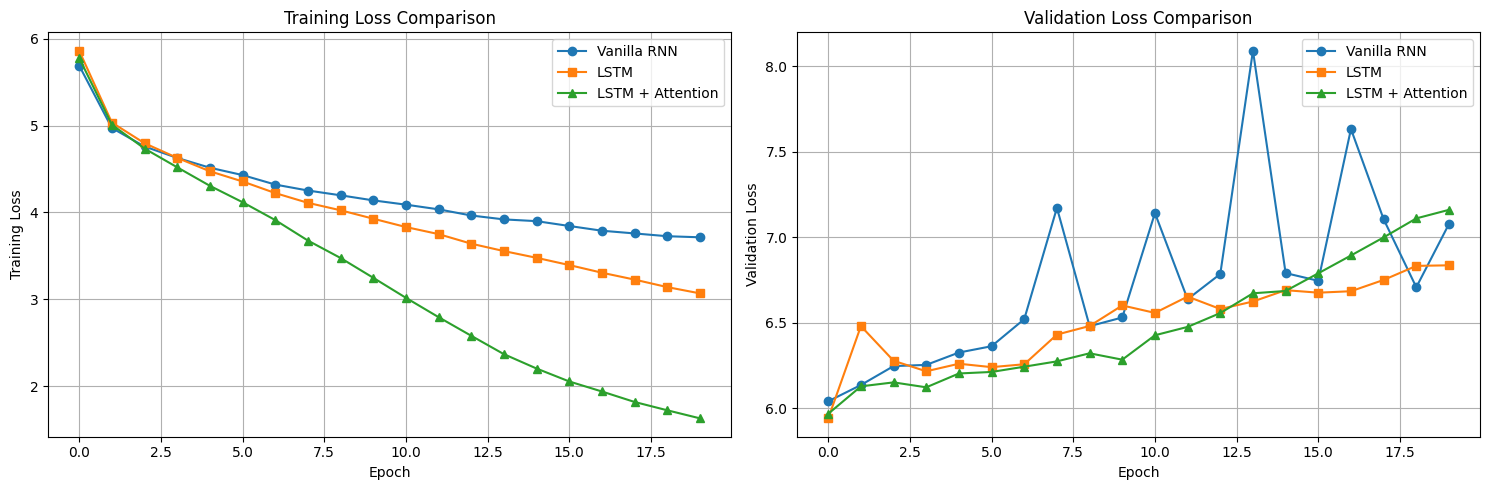

 Training curves saved to Google Drive!


In [18]:
# Visualizations

with open(os.path.join(PROJECT_DIR, 'vanilla_rnn_losses.pkl'), 'rb') as f:
    rnn_losses = pickle.load(f)
    train_losses_rnn = rnn_losses['train']
    val_losses_rnn = rnn_losses['val']

with open(os.path.join(PROJECT_DIR, 'lstm_losses.pkl'), 'rb') as f:
    lstm_losses = pickle.load(f)
    train_losses_lstm = lstm_losses['train']
    val_losses_lstm = lstm_losses['val']

with open(os.path.join(PROJECT_DIR, 'lstm_attention_losses.pkl'), 'rb') as f:
    attn_losses = pickle.load(f)
    train_losses_attn = attn_losses['train']
    val_losses_attn = attn_losses['val']

print(" Training losses loaded from Google Drive!")

# Plot training curves
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

axes[0].plot(train_losses_rnn, label='Vanilla RNN', marker='o')
axes[0].plot(train_losses_lstm, label='LSTM', marker='s')
axes[0].plot(train_losses_attn, label='LSTM + Attention', marker='^')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Training Loss')
axes[0].set_title('Training Loss Comparison')
axes[0].legend()
axes[0].grid(True)

axes[1].plot(val_losses_rnn, label='Vanilla RNN', marker='o')
axes[1].plot(val_losses_lstm, label='LSTM', marker='s')
axes[1].plot(val_losses_attn, label='LSTM + Attention', marker='^')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Validation Loss')
axes[1].set_title('Validation Loss Comparison')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.savefig(os.path.join(PROJECT_DIR, 'training_curves.png'), dpi=300, bbox_inches='tight')
plt.show()

print(" Training curves saved to Google Drive!")

### bleu distribution on test code

In [19]:
# bleu distribution on test code

from sacrebleu.metrics import BLEU
from tqdm import tqdm

def calculate_per_example_bleu(model, test_data, src_vocab, tgt_vocab, device, model_type='rnn'):
    bleu = BLEU()
    per_example_scores = []

    for pair in tqdm(test_data, desc=f"Calculating per-example BLEU ({model_type})"):
        src = pair['docstring']
        tgt = pair['code']
        print(f"Source: {src}")
        print(f"Target: {tgt}")

        pred_indices, _ = translate_sentence(model, src, src_vocab, tgt_vocab, device, model_type=model_type)
        pred_tokens = [tgt_vocab.idx2word.get(idx, '') for idx in pred_indices if idx not in [SOS_IDX, EOS_IDX]]

        score = bleu.sentence_score(' '.join(pred_tokens), [tgt]).score
        per_example_scores.append(score)

    return per_example_scores


Calculating per-example BLEU (rnn):   1%|          | 8/1500 [00:00<00:18, 79.39it/s]WARNING:sacrebleu:It is recommended to enable `effective_order` for sentence-level BLEU.


Source: Maximizes the current window that webdriver is using
Target: def maximize_window ( self ) : params = None command = Command . W3C_MAXIMIZE_WINDOW if not self . w3c : command = Command . MAXIMIZE_WINDOW params = { 'windowHandle' : 'current' } self . execute ( command , params )
Source: Allow the session to be discarded and don t get change notifications from it anymore
Target: def detach_session ( self ) : if self . _session is not None : self . _session . unsubscribe ( self ) self . _session = None
Source: Add a text entry to be logged during : meth : commit .
Target: def log_text ( self , text , * * kw ) : self . entries . append ( TextEntry ( payload = text , * * kw ) )
Source: 市价买入 : param security : 六位证券代码 : param amount : 交易数量 : param ttype : 市价委托类型，默认客户端默认选择， 深市可选 [ 对手方最优价格 本方最优价格 即时成交剩余撤销 最优五档即时成交剩余 全额成交或撤销 ] 沪市可选 [ 最优五档成交剩余撤销 最优五档成交剩余转限价 ]
Target: def market_buy ( self , security , amount , ttype = None , * * kwargs ) : self . _switch_left_menus ( [ "市价委托", "买入"])     r

Calculating per-example BLEU (rnn):   2%|▏         | 25/1500 [00:00<00:18, 79.22it/s]WARNING:sacrebleu:It is recommended to enable `effective_order` for sentence-level BLEU.


Source: Return a shell - escaped version of the string s .
Target: def quote ( self , s ) : if six . PY2 : from pipes import quote else : from shlex import quote return quote ( s )
Source: Return a fully - qualified project_job_trigger string .
Target: def project_job_trigger_path ( cls , project , job_trigger ) : return google . api_core . path_template . expand ( "projects/{project}/jobTriggers/{job_trigger}" , project = project , job_trigger = job_trigger , )
Source: Batch indices corresponding to the examples in the per - expert Tensor s .
Target: def expert_to_batch_indices ( self ) : return tf . split ( self . _batch_index , self . _part_sizes_tensor , 0 , num = self . _num_experts )
Source: Set the scroll region on the canvas
Target: def set_scrollregion ( self , event = None ) : self . canvas . configure ( scrollregion = self . canvas . bbox ( 'all' ) )
Source: Stops listening for new connections .
Target: def stop ( self ) -> None : if self . _stopped : return self . _stopped 

Calculating per-example BLEU (rnn):   3%|▎         | 43/1500 [00:00<00:17, 82.96it/s]WARNING:sacrebleu:It is recommended to enable `effective_order` for sentence-level BLEU.


...

Source: Return current line s text
Target: def get_current_line ( self ) : cursor = self . textCursor ( ) cursor . select ( QTextCursor . BlockUnderCursor ) return to_text_string ( cursor . selectedText ( ) )
Source: 返回一个基于代码的迭代器
Target: def security_gen ( self ) : for item in self . index . levels [ 1 ] : yield self . new ( self . data . xs ( item , level = 1 , drop_level = False ) , dtype = self . type , if_fq = self . if_fq )
Source: Get attribute string from the Booster .
Target: def attr ( self , key ) : ret = ctypes . c_char_p ( ) success = ctypes . c_int ( ) _check_call ( _LIB . XGBoosterGetAttr ( self . handle , c_str ( key ) , ctypes . byref ( ret ) , ctypes . byref ( success ) ) ) if success . value != 0 : return py_str ( ret . value ) return None
Source: Return the address of the network
Target: def get_net_start ( ipaddr , netmask ) : net = ipaddress . ip_network ( '{0}/{1}' . format ( ipaddr , netmask ) , strict = False ) return six . text_type ( net . network_address )
So

Calculating per-example BLEU (attention):  99%|█████████▉| 1492/1500 [00:45<00:00, 42.15it/s]WARNING:sacrebleu:It is recommended to enable `effective_order` for sentence-level BLEU.


Source: Consumes protocol message field identifier .
Target: def ConsumeIdentifierOrNumber ( self ) : result = self . token if not self . _IDENTIFIER_OR_NUMBER . match ( result ) : raise self . ParseError ( 'Expected identifier or number.' ) self . NextToken ( ) return result
Source: Gets the resource at the given logicalId if present
Target: def get ( self , logicalId ) : if logicalId not in self . resources : return None return SamResource ( self . resources . get ( logicalId ) )
Source: Reimplement the IPython context menu
Target: def _context_menu_make ( self , pos ) : menu = super ( ShellWidget , self ) . _context_menu_make ( pos ) return self . ipyclient . add_actions_to_context_menu ( menu )
Source: Overridden method to join grouped columns in output
Target: def _fill ( self , direction , limit = None ) : res = super ( ) . _fill ( direction , limit = limit ) output = OrderedDict ( ( grp . name , grp . grouper ) for grp in self . grouper . groupings ) from pandas import concat re

Calculating per-example BLEU (attention): 100%|██████████| 1500/1500 [00:45<00:00, 32.81it/s]
/tmp/ipython-input-681/340772412.py:18: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(


Source: Yields successive checkpoints from model_dir .
Target: def next_checkpoint ( model_dir , timeout_mins = 240 ) : last_ckpt = None timeout_secs = None if timeout_mins != - 1 : timeout_secs = timeout_mins * 60 while True : last_ckpt = tf . contrib . training . wait_for_new_checkpoint ( model_dir , last_ckpt , seconds_to_sleep = 60 , timeout = timeout_secs ) if last_ckpt is None : tf . logging . info ( "Eval timeout: no new checkpoints within %dm" % timeout_mins ) break yield last_ckpt
Source: Returns a lookup table of reverse dependencies for all the given cache keys .
Target: def _reverse_dependencies ( self , cache_keys ) : # First, collect all the dependencies into a sequence of (parent, child) tuples, like [('flake8', 'pep8'), # ('flake8', 'mccabe'), ...] return lookup_table ( ( key_from_req ( Requirement ( dep_name ) ) , name ) for name , version_and_extras in cache_keys for dep_name in self . cache [ name ] [ version_and_extras ] )
Source: Return a new DStream by applying co

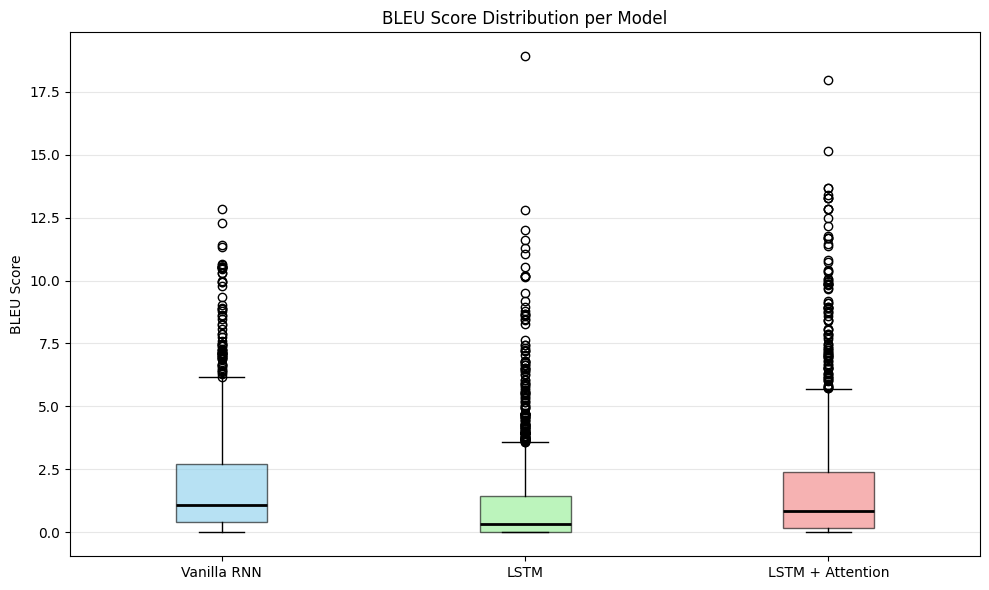

In [20]:


bleu_rnn_scores = calculate_per_example_bleu(model_rnn, test_data, src_vocab, tgt_vocab, device, 'rnn')
bleu_lstm_scores = calculate_per_example_bleu(model_lstm, test_data, src_vocab, tgt_vocab, device, 'lstm')
bleu_attn_scores = calculate_per_example_bleu(model_attention, test_data, src_vocab, tgt_vocab, device, 'attention')

all_res = {
    'Vanilla RNN': {'bleu_scores': bleu_rnn_scores},
    'LSTM': {'bleu_scores': bleu_lstm_scores},
    'LSTM + Attention': {'bleu_scores': bleu_attn_scores}
}

names = ['Vanilla RNN', 'LSTM', 'LSTM + Attention']
colors = ['skyblue', 'lightgreen', 'lightcoral']

import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10,6))

bp = ax.boxplot(
    [all_res[n]['bleu_scores'] for n in names],
    labels=names,
    patch_artist=True,
    medianprops=dict(color='black', lw=2)
)

for p, c in zip(bp['boxes'], colors):
    p.set_facecolor(c)
    p.set_alpha(0.6)

ax.set(ylabel='BLEU Score', title='BLEU Score Distribution per Model')
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(PROJECT_DIR, 'bleu_distribution.png'), dpi=300, bbox_inches='tight')
plt.show()


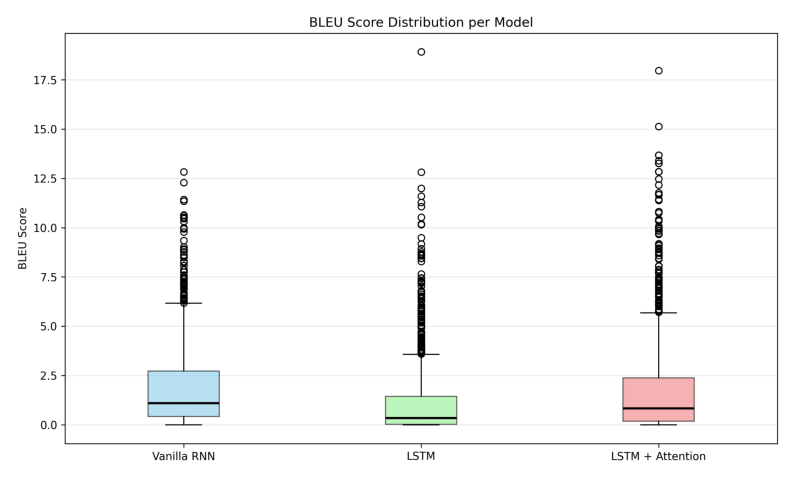

In [21]:
import os
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

img_path = os.path.join(PROJECT_DIR, 'bleu_distribution.png')

img = mpimg.imread(img_path)
plt.figure(figsize=(10,6))
plt.imshow(img)
plt.axis('off')
plt.show()


### error

In [22]:


import ast
from collections import defaultdict

# ==============================
# 3️⃣ Types of Errors Analysis
# ==============================

def analyze_code_errors(pred_code, ref_code):
    """
    Analyze errors in a predicted Python code string.
    Returns counts for:
    - Syntax errors
    - Indentation errors
    - Incorrect operators/variables
    """

    samples = [
        {'reference': ref_code, 'generated': pred_code}
    ]
    syntax_errors = 0
    missing_indentation = 0; incorrect_operators = 0 ; missing_tokens = 0;extra_tokens = 0; total_errors = 0;
    ops = {'+','-','*','/','==','!=','>=','<=','>','<','and','or','not','in','is'}
    for s in samples:
        r, g = s['reference'], s['generated']
        if r==g: continue
        total_errors += 1
        if 'INDENT' in r and 'INDENT' not in g: missing_indentation += 1
        if {t for t in r.split() if t in ops} != {t for t in g.split() if t in ops}: incorrect_operators += 1
        rl, gl = len(r.split()), len(g.split())
        if gl<rl: missing_tokens += 1
        elif gl>rl: extra_tokens += 1
        try: compile(g.replace('NEWLINE','\n').replace('INDENT','    '),'<s>','exec')
        except SyntaxError: syntax_errors += 1

    return syntax_errors, missing_indentation, incorrect_operators, missing_tokens, extra_tokens, total_errors


error_summary = defaultdict(lambda: {'syntax_errors':0,'missing_indentation':0,'incorrect_operators':0,'missing_tokens':0,'extra_tokens':0,'total_errors':0})

for model_name, model, mtype in [
    ('Vanilla RNN', model_rnn, 'rnn'),
    ('LSTM', model_lstm, 'lstm'),
    ('LSTM + Attention', model_attention, 'attention')
]:
    for example in tqdm(test_data[:100], desc=f"Analyzing errors for {model_name}"):
        src = example['docstring']
        tgt = example['code']

        pred_indices, _ = translate_sentence(model, src, src_vocab, tgt_vocab, device, model_type=mtype)
        pred_tokens = [tgt_vocab.idx2word.get(idx, '') for idx in pred_indices if idx not in [SOS_IDX, EOS_IDX]]
        pred_code = ' '.join(pred_tokens)

        syntax_err, missing_ind, in_oper, missing_t, extra_t, total_errors = analyze_code_errors(pred_code, tgt)
        error_summary[model_name]['syntax_errors'] += syntax_err
        error_summary[model_name]['missing_indentation'] += missing_ind
        error_summary[model_name]['incorrect_operators'] += in_oper
        error_summary[model_name]['missing_tokens'] += missing_t
        error_summary[model_name]['extra_tokens'] += extra_t
        error_summary[model_name]['total_errors'] += total_errors





Analyzing errors for LSTM + Attention: 100%|██████████| 100/100 [00:02<00:00, 46.65it/s]


In [23]:
import pandas as pd

df_errors = pd.DataFrame(error_summary).T
df_errors['Total Examples'] = len(test_data[:100])
df_errors['Syntax Error (%)'] = df_errors['syntax_errors'] / df_errors['Total Examples'] * 100
df_errors['Indentation Error (%)'] = df_errors['missing_indentation'] / df_errors['Total Examples'] * 100
df_errors['Operator/Var Error (%)'] = df_errors['incorrect_operators'] / df_errors['Total Examples'] * 100
df_errors['Missing Tokens (%)'] = df_errors['missing_tokens'] / df_errors['Total Examples'] * 100
df_errors['Extra Tokens (%)'] = df_errors['extra_tokens'] / df_errors['Total Examples'] * 100


df_errors = df_errors[['Total Examples', 'Indentation Error (%)', 'Operator/Var Error (%)', 'Missing Tokens (%)', 'Extra Tokens (%)' ]]
print("\n--- Error Analysis Summary ---")
print(df_errors)

df_errors.to_csv(os.path.join(PROJECT_DIR, 'error_analysis_summary.csv'), index=True)
print("\nError analysis saved to CSV!")





--- Error Analysis Summary ---
                  Total Examples  Indentation Error (%)  \
Vanilla RNN                  100                    0.0   
LSTM                         100                    0.0   
LSTM + Attention             100                    0.0   

                  Operator/Var Error (%)  Missing Tokens (%)  Extra Tokens (%)  
Vanilla RNN                         66.0               100.0               0.0  
LSTM                                68.0                98.0               2.0  
LSTM + Attention                    65.0                99.0               1.0  

Error analysis saved to CSV!


### BLEU score vs docstring length

In [24]:
from nltk.translate.bleu_score import sentence_bleu
from collections import defaultdict
import numpy as np

def bleu_vs_length(model, model_type, data, src_vocab, tgt_vocab, device, bin_size=10):
    """
    Compute average BLEU score vs docstring length (binned)
    """
    length_bins = defaultdict(list)


    for example in tqdm(data, desc=f"Computing BLEU for {model_type}"):
        src = example['docstring']
        tgt = example['code']

        # Predict code
        pred_indices, _ = translate_sentence(model, src, src_vocab, tgt_vocab, device, model_type=model_type)
        pred_tokens = [tgt_vocab.idx2word.get(idx, '') for idx in pred_indices if idx not in [SOS_IDX, EOS_IDX]]
        pred_code = ' '.join(pred_tokens)

        # BLEU score
        reference_tokens = tgt.split()
        bleu_score = sentence_bleu([reference_tokens], pred_tokens, weights=(0.5, 0.5))  # or adjust weights

        # Bin docstring length
        # length_bin = (len(src.split()) // bin_size) * bin_size
        # inside bleu_vs_length function
        length_bin = (len(src.split()) // bin_size + 1) * bin_size  # shift bin up
        length_bins[length_bin].append(bleu_score)

    # Compute average BLEU per bin
    avg_bleu_per_bin = {k: np.mean(v) for k, v in length_bins.items()}
    return avg_bleu_per_bin


Computing BLEU vs length: Vanilla RNN...


Computing BLEU for rnn: 100%|██████████| 100/100 [00:02<00:00, 36.79it/s]


Computing BLEU vs length: LSTM...


Computing BLEU for lstm: 100%|██████████| 100/100 [00:01<00:00, 84.49it/s]


Computing BLEU vs length: LSTM + Attention...


Computing BLEU for attention: 100%|██████████| 100/100 [00:02<00:00, 46.07it/s]


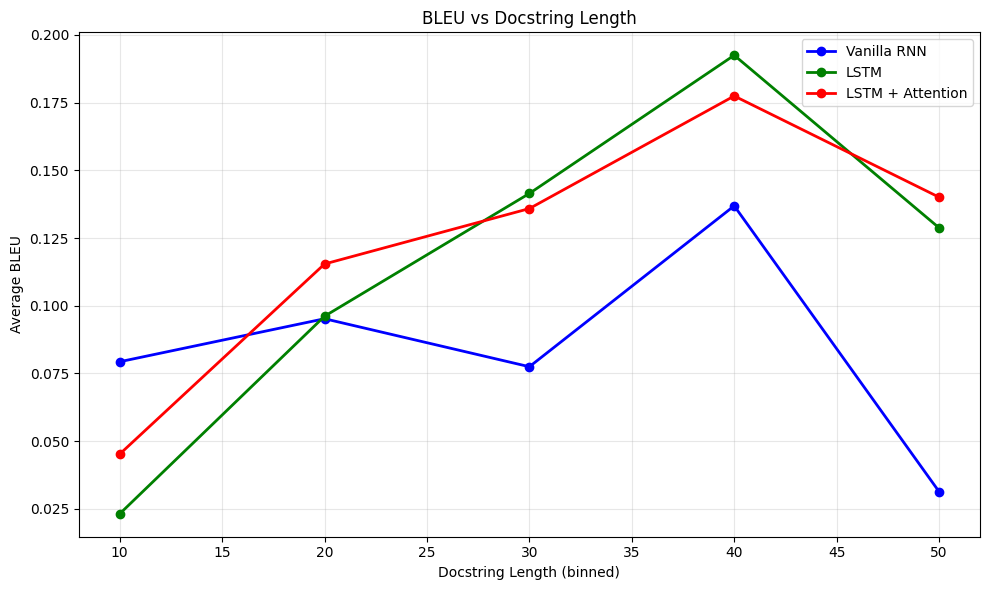

BLEU score vs docstring length saved to Google Drive!


<Figure size 640x480 with 0 Axes>

In [28]:
import matplotlib.pyplot as plt

model_map = {
    'Vanilla RNN': (model_rnn, 'rnn'),
    'LSTM': (model_lstm, 'lstm'),
    'LSTM + Attention': (model_attention, 'attention')
}

colors = ['blue', 'green', 'red']
fig, ax = plt.subplots(figsize=(10,6))

for (model_name, (model, model_type)), color in zip(model_map.items(), colors):
    print(f'Computing BLEU vs length: {model_name}...')
    lb = bleu_vs_length(model, model_type, test_data[:100], src_vocab, tgt_vocab, device, bin_size=10)
    bins = sorted(lb.keys())
    ax.plot(bins, [lb[b] for b in bins], marker='o', label=model_name, color=color, lw=2)

ax.set(
    xlabel='Docstring Length (binned)',
    ylabel='Average BLEU',
    title='BLEU vs Docstring Length'
)
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()
plt.savefig("BLEU score vs docstring length.png")
print("BLEU score vs docstring length saved to Google Drive!")


### Attention Analysis

Generating attention visualizations...

--- Example 1 ---
Source: Maximizes the current window that webdriver is using
Target: def maximize_window ( self ) : params = None command = Command . W3C_MAXIMIZE_WINDOW if not self . w3c : command = Command . MAXIMIZE_WINDOW params = { 'windowHandle' : 'current' } self . execute ( command , params )
Predicted: def _default ( self , : ) : if = self . . ( ) )


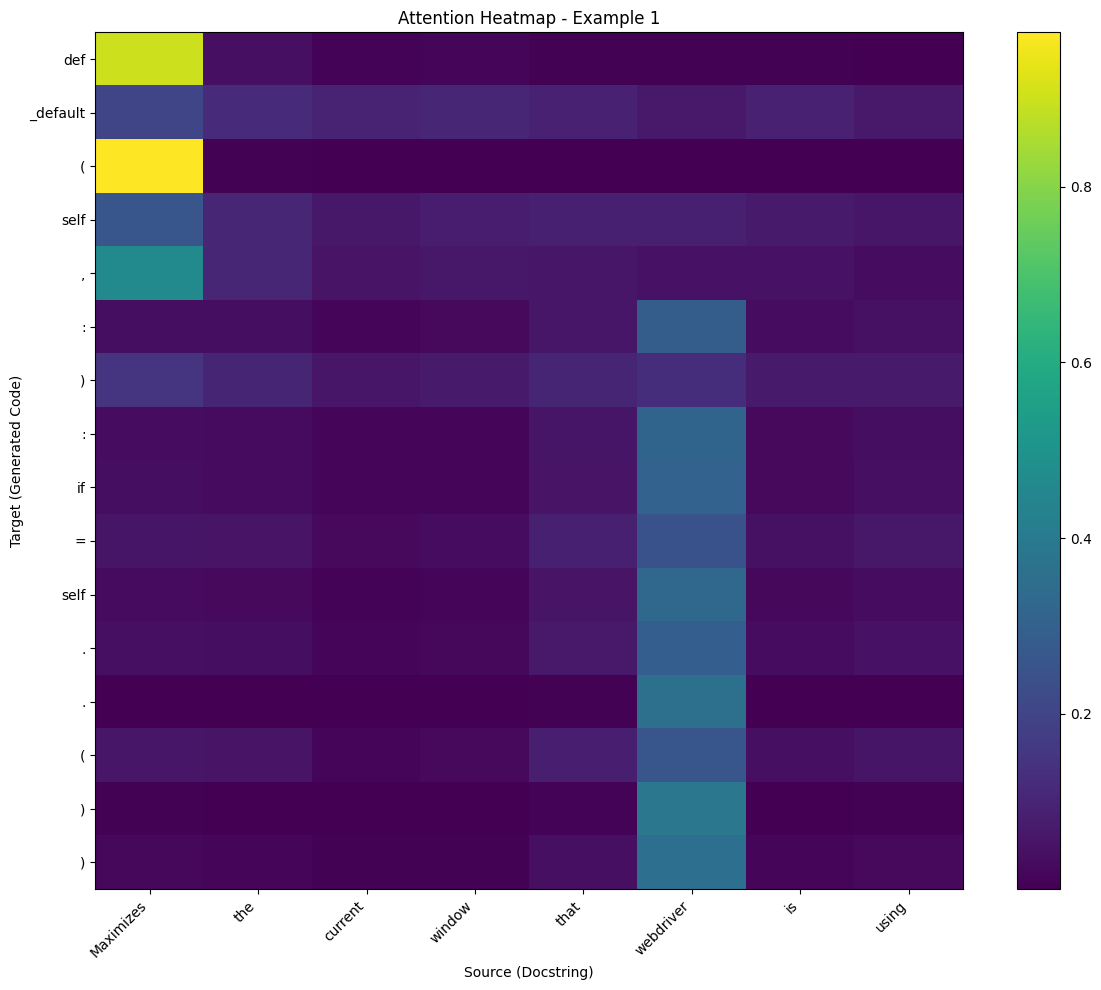


--- Example 2 ---
Source: Allow the session to be discarded and don t get change notifications from it anymore
Target: def detach_session ( self ) : if self . _session is not None : self . _session . unsubscribe ( self ) self . _session = None
Predicted: def _default ( self , : ) : if = self . : ( self . ) ( ) )


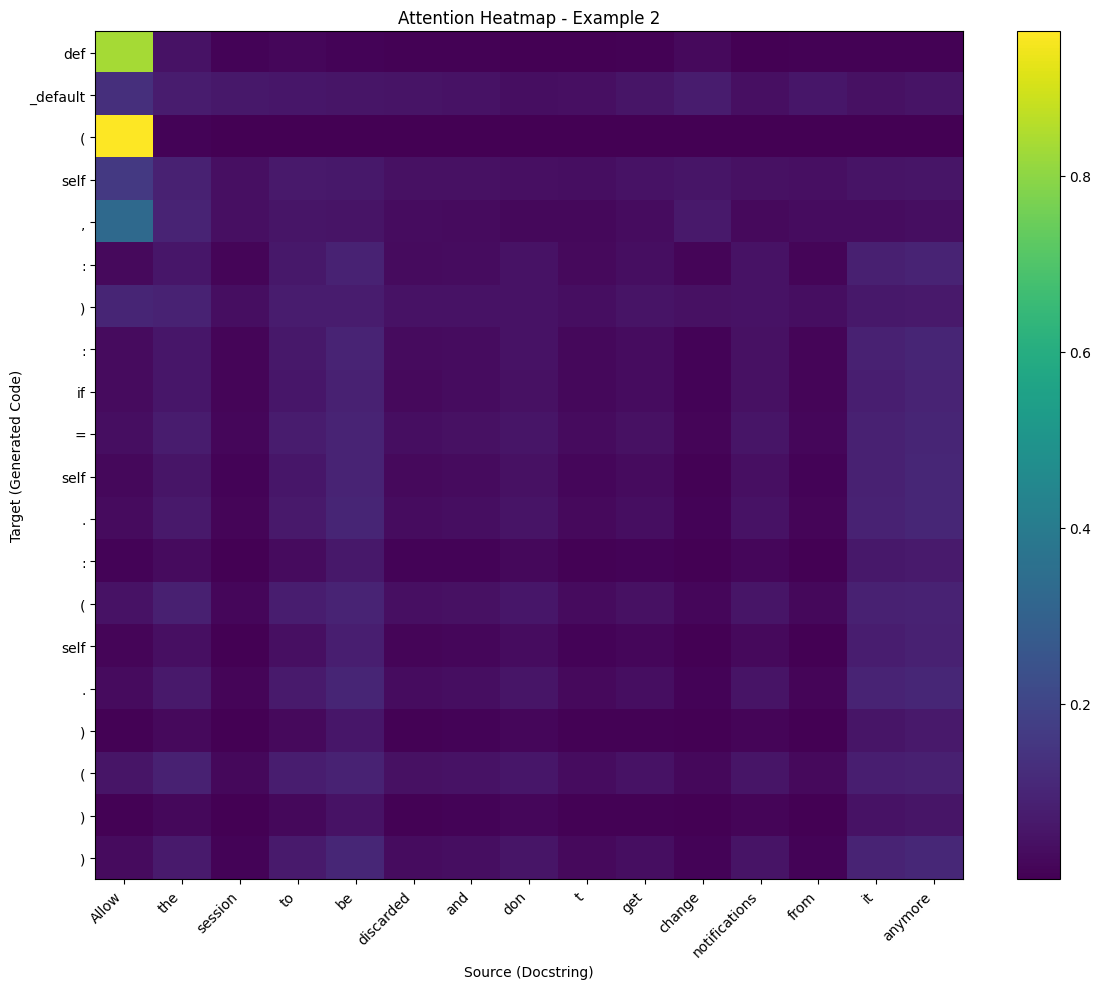


--- Example 3 ---
Source: Add a text entry to be logged during : meth : commit .
Target: def log_text ( self , text , * * kw ) : self . entries . append ( TextEntry ( payload = text , * * kw ) )
Predicted: def _default ( self , : , : = None : if = self . : ( ) )


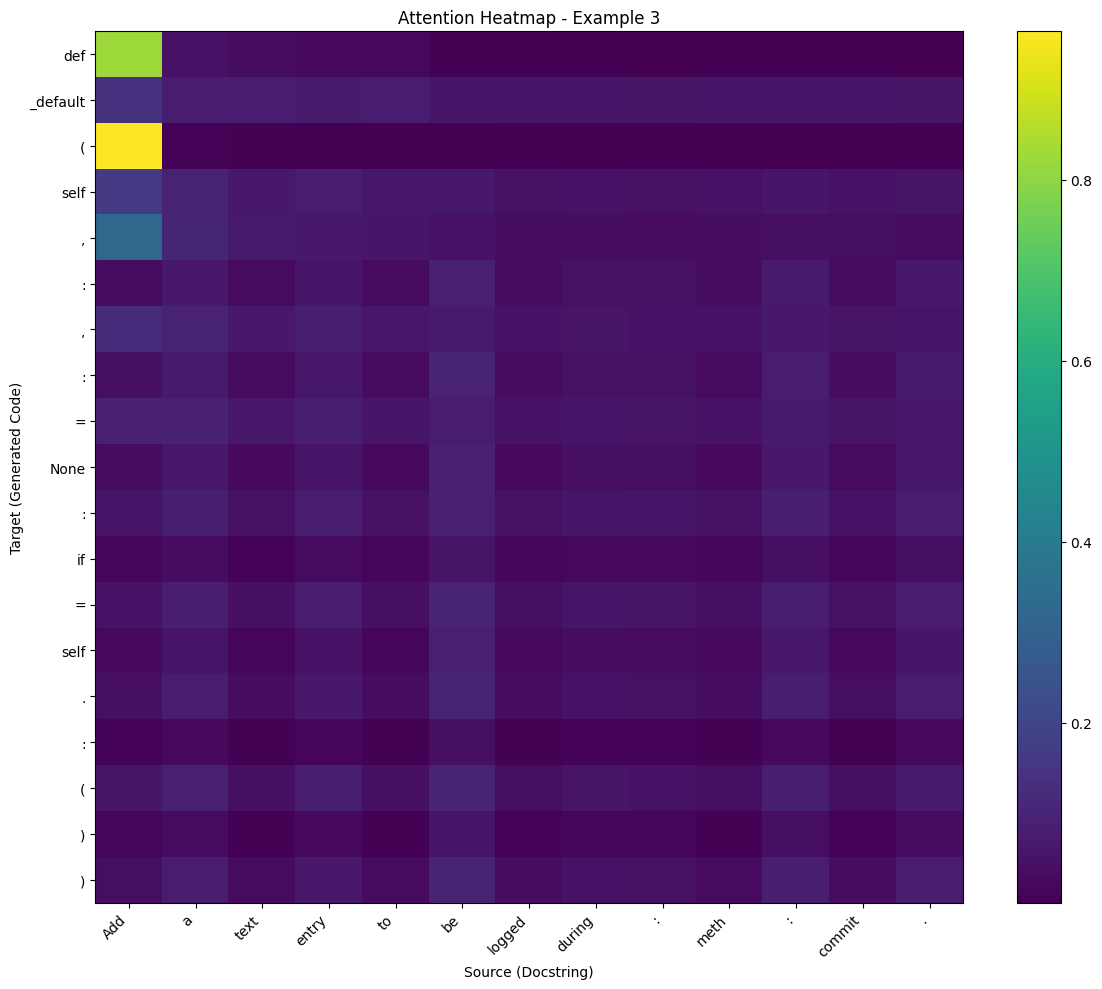


All visualizations saved to Google Drive!


In [29]:
# Attention Visualization
def plot_attention(src_tokens, tgt_tokens, attention_weights, example_num):
    fig, ax = plt.subplots(figsize=(12, 10))

    attention = attention_weights[:len(tgt_tokens), :len(src_tokens)]

    im = ax.imshow(attention, cmap='viridis', aspect='auto')

    ax.set_xticks(range(len(src_tokens)))
    ax.set_yticks(range(len(tgt_tokens)))
    ax.set_xticklabels(src_tokens, rotation=45, ha='right')
    ax.set_yticklabels(tgt_tokens)

    ax.set_xlabel('Source (Docstring)')
    ax.set_ylabel('Target (Generated Code)')
    ax.set_title(f'Attention Heatmap - Example {example_num}')

    plt.colorbar(im, ax=ax)
    plt.tight_layout()
    plt.savefig(os.path.join(PROJECT_DIR, f'attention_example_{example_num}.png'), dpi=300, bbox_inches='tight')
    plt.show()

print("Generating attention visualizations...")
for i in range(3):
    example = test_data[i]
    src = example['docstring']
    tgt = example['code']

    pred_indices, attention_weights = translate_sentence(
        model_attention, src, src_vocab, tgt_vocab, device, model_type='attention')

    src_tokens = src.split()
    pred_tokens = [tgt_vocab.idx2word.get(idx, '') for idx in pred_indices
                  if idx not in [SOS_IDX, EOS_IDX]
                  ]

    print(f"\n--- Example {i+1} ---")
    print(f"Source: {src}")
    print(f"Target: {tgt}")
    print(f"Predicted: {' '.join(pred_tokens)}")

    if attention_weights is not None and len(attention_weights) > 0:
        plot_attention(src_tokens, pred_tokens, attention_weights, i+1)

print("\nAll visualizations saved to Google Drive!")

### bonus

